# CryoBoltz Dataset Inspection

This notebook lets you inspect the cryo-EM maps and PDB structures used in the
[CryoBoltz paper](https://arxiv.org/abs/2506.04490).

**Run `bash download_data.sh` first** to fetch the raw data into this folder.

## Datasets
| Target | Type | EMDB | PDB |
|---|---|---|---|
| P-gp apo | real map | 40226 | 8GMG |
| P-gp inward | real map | 40259 | 8SA1 |
| P-gp occluded | real map | 40258 | 8SA0 |
| P-gp collapsed | real map | 40227 | 8GMJ |
| Pma1 (README eg) | real map | 64136 | 9UGC |
| STP10 inward | synthetic | — | 7AAQ |
| STP10 outward | synthetic | — | 7AAR |
| CH67 antibody | synthetic | — | 4HKX |

Synthetic maps must be generated from PDB structures using ChimeraX `molmap` — see cell below.

In [1]:
import subprocess, sys

# Install mrcfile if not present (lightweight, no heavy deps)
try:
    import mrcfile
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mrcfile", "-q"])
    import mrcfile

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CRYO_DIR = Path(".")   # cryo/ folder
print("mrcfile version:", mrcfile.__version__)

mrcfile version: 1.5.4


## 1. Check what was downloaded

In [2]:
map_files = sorted(CRYO_DIR.rglob("*.map"))
pdb_files = sorted(CRYO_DIR.rglob("*.pdb"))
cif_files = sorted(CRYO_DIR.rglob("*.cif"))

print(f"Found {len(map_files)} .map files, {len(pdb_files)} .pdb files, {len(cif_files)} .cif files")
for f in map_files:
    print(f"  {f}  ({f.stat().st_size/1e6:.1f} MB)")

Found 4 .map files, 4 .pdb files, 4 .cif files
  pgp/apo/emd_40226.map  (28.3 MB)
  pgp/collapsed/emd_40227.map  (8.5 MB)
  pgp/inward/emd_40259.map  (28.3 MB)
  pgp/occluded/emd_40258.map  (28.3 MB)


## 2. Inspect a single cryo-EM map

In [3]:
def inspect_map(path):
    """Print key metadata and return the data array."""
    with mrcfile.open(str(path), mode='r', permissive=True) as mrc:
        data  = mrc.data.copy()
        vsize = mrc.voxel_size
        print(f"File:        {path.name}")
        print(f"Shape:       {data.shape}  (z, y, x)")
        print(f"Dtype:       {data.dtype}")
        print(f"Voxel size:  x={float(vsize.x):.3f} Å  y={float(vsize.y):.3f} Å  z={float(vsize.z):.3f} Å")
        print(f"Data range:  min={data.min():.4f}  max={data.max():.4f}  mean={data.mean():.4f}")
        print(f"Map extent:  {data.shape[2]*float(vsize.x):.1f} x {data.shape[1]*float(vsize.y):.1f} x {data.shape[0]*float(vsize.z):.1f} Å")
    return data

if map_files:
    data = inspect_map(map_files[0])
else:
    print("No .map files found — run bash download_data.sh first.")
    data = None

File:        emd_40226.map
Shape:       (192, 192, 192)  (z, y, x)
Dtype:       float32
Voxel size:  x=1.060 Å  y=1.060 Å  z=1.060 Å
Data range:  min=-0.1358  max=0.2013  mean=0.0003
Map extent:  203.5 x 203.5 x 203.5 Å


## 3. Visualize central slices

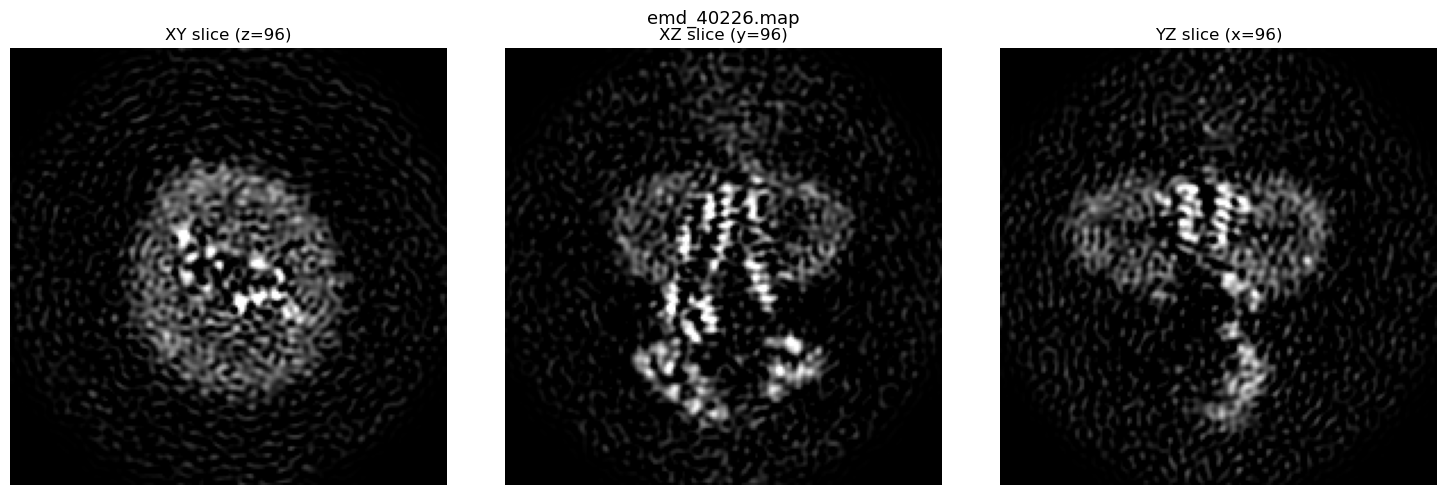

In [4]:
def plot_slices(data, title="", vmin_pct=50, vmax_pct=99.9):
    """Show XY, XZ, YZ central slices of a 3-D density map."""
    if data is None:
        return
    nz, ny, nx = data.shape
    vmin = np.percentile(data, vmin_pct)
    vmax = np.percentile(data, vmax_pct)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(data[nz//2, :, :], cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    axes[0].set_title(f"XY slice (z={nz//2})")
    axes[1].imshow(data[:, ny//2, :], cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    axes[1].set_title(f"XZ slice (y={ny//2})")
    axes[2].imshow(data[:, :, nx//2], cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    axes[2].set_title(f"YZ slice (x={nx//2})")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title or "Cryo-EM density map", fontsize=13)
    plt.tight_layout()
    plt.show()

if data is not None:
    plot_slices(data, title=map_files[0].name)

## 4. Inspect all downloaded maps

In [5]:
summary = []
for mf in map_files:
    try:
        with mrcfile.open(str(mf), mode='r', permissive=True) as mrc:
            d = mrc.data
            vs = mrc.voxel_size
            summary.append({
                "file": mf.name,
                "parent": mf.parent.name,
                "shape": d.shape,
                "voxel_A": round(float(vs.x), 3),
                "extent_A": round(d.shape[2]*float(vs.x), 1),
                "size_MB": round(mf.stat().st_size/1e6, 1),
                "density_max": round(float(d.max()), 4),
            })
    except Exception as e:
        summary.append({"file": mf.name, "error": str(e)})

import pandas as pd
pd.DataFrame(summary)

,file,parent,shape,voxel_A,extent_A,size_MB,density_max
0,emd_40226.map,apo,"(192, 192, 192)",1.06,203.5,28.3,0.2013
1,emd_40227.map,collapsed,"(147, 119, 121)",1.06,128.3,8.5,0.1332
2,emd_40259.map,inward,"(192, 192, 192)",1.06,203.5,28.3,0.1562
3,emd_40258.map,occluded,"(192, 192, 192)",1.06,203.5,28.3,0.1351


## 5. Quick look at a PDB / CIF structure

In [6]:
def parse_pdb_atoms(path):
    """Parse ATOM/HETATM lines from a PDB file — no biopython needed."""
    records = []
    with open(path) as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                records.append({
                    "record": line[:6].strip(),
                    "atom": line[12:16].strip(),
                    "resname": line[17:20].strip(),
                    "chain": line[21].strip(),
                    "resseq": int(line[22:26]),
                    "x": float(line[30:38]),
                    "y": float(line[38:46]),
                    "z": float(line[46:54]),
                    "element": line[76:78].strip() if len(line) > 76 else "",
                })
    return pd.DataFrame(records)

if pdb_files:
    pf = pdb_files[0]
    atoms = parse_pdb_atoms(pf)
    print(f"{pf.name}: {len(atoms)} atom records")
    print(f"Chains: {sorted(atoms['chain'].unique())}")
    print(f"Residues: {atoms['resseq'].nunique()}")
    print(f"HETATM (ligands/waters): {(atoms['record']=='HETATM').sum()}")
    print()
    atoms.head(10)
else:
    print("No PDB files found — run bash download_data.sh first.")

8GMG.pdb: 9770 atom records
Chains: ['A']
Residues: 1158
HETATM (ligands/waters): 0



## 6. Density histogram (non-zero voxels)

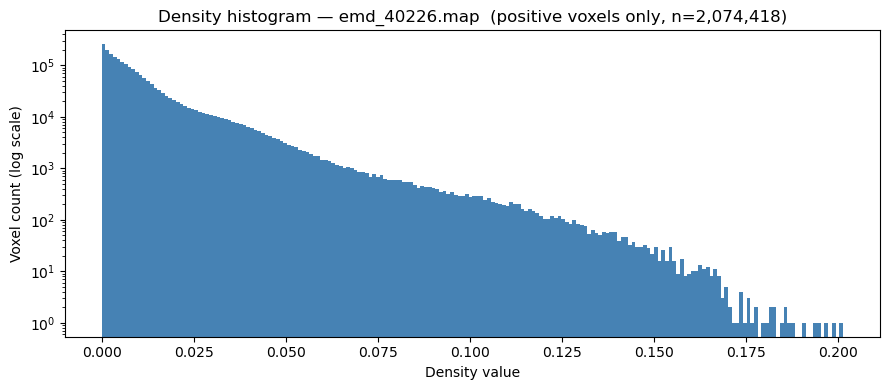

Suggested map threshold (≈ 0.5σ above mean): 0.0183


In [7]:
if data is not None:
    flat = data.ravel()
    pos  = flat[flat > 0]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(pos, bins=200, color="steelblue", edgecolor="none", log=True)
    ax.set_xlabel("Density value")
    ax.set_ylabel("Voxel count (log scale)")
    ax.set_title(f"Density histogram — {map_files[0].name}  (positive voxels only, n={len(pos):,})")
    plt.tight_layout()
    plt.show()
    print(f"Suggested map threshold (≈ 0.5σ above mean): {pos.mean() + 0.5*pos.std():.4f}")

## 7. Generate a synthetic map from a PDB structure (ChimeraX)

The STP10 and CH67 maps in the CryoBoltz paper were generated via ChimeraX's `molmap` command.
If ChimeraX is installed, run:

```bash
# Activate ChimeraX and generate 2 Å synthetic map for STP10
chimerax --nogui --script - <<'EOF'
open synthetic/stp10/7AAQ.pdb
molmap #1 2.0 gridSpacing 1.0
save synthetic/stp10/7AAQ_2A.mrc models #2
stop
EOF
```

## 8. 3D Visualization

Two complementary views of the cryo-EM density:

| | Tool | Interactivity | Best for |
|---|---|---|---|
| **8a** | `nglview` | full molecular viewer (rotate/zoom/pan) | density + protein overlay |
| **8b** | `plotly` | interactive mesh (WebGL) | density shape at a glance |

Both use an automatic isosurface threshold of **≈ 1σ above the mean of positive voxels**.
Adjust `threshold` / `step` to taste.


In [9]:

# ── nglview: interactive density surface + protein Cα trace ───────────────────
# The widget is fully interactive: rotate (left-drag), zoom (scroll), pan (right-drag).
# nglview loads the .map file as CCP4/MRC density and overlays the PDB cartoon.
import nglview as nv
from IPython.display import display

if not map_files or not pdb_files:
    print("No data found — run bash download_data.sh first.")
else:
    map_path = map_files[0]
    pdb_path = pdb_files[0]

    # Determine a sensible isosurface level (≈ 1σ of positive voxels)
    with mrcfile.open(str(map_path), mode='r', permissive=True) as mrc:
        d = mrc.data
    pos = d[d > 0]
    threshold = float(pos.mean() + pos.std())
    print(f"Map  : {map_path}")
    print(f"PDB  : {pdb_path}")
    print(f"Level: {threshold:.4f}  (~1σ)")

    view = nv.NGLWidget()
    view._remote_call("setSize", target="Widget", args=["720px", "520px"])

    # Density map — transparent blue surface
    map_comp = view.add_component(str(map_path), ext="ccp4")
    map_comp.clear_representations()
    map_comp.add_representation(
        "surface",
        isolevel=threshold,
        isolevelType="value",
        opacity=0.35,
        color="skyblue",
        side="front",
    )

    # Protein — cartoon coloured by chain
    pdb_comp = view.add_component(str(pdb_path))
    pdb_comp.clear_representations()
    pdb_comp.add_representation("cartoon", color="chainid", opacity=1.0)

    view.center()
    display(view)


Map  : pgp/apo/emd_40226.map
PDB  : pgp/apo/8GMG.pdb
Level: 0.0256  (~1σ)


NGLWidget()

In [10]:

# ── Plotly 3D isosurface via marching cubes ────────────────────────────────────
# Works in any Jupyter front-end (no external kernel widget needed).
# The map is downsampled 2× so the mesh stays manageable.
from skimage import measure
import plotly.graph_objects as go

if data is not None:
    step = 2
    d_small = data[::step, ::step, ::step]

    with mrcfile.open(str(map_files[0]), mode='r', permissive=True) as mrc:
        vs = float(mrc.voxel_size.x)
    vs_scaled = vs * step  # Å per downsampled voxel

    # Threshold ≈ 1σ above mean of positive voxels (good starting point for EMDB maps)
    pos  = data[data > 0]
    iso  = float(pos.mean() + pos.std())
    print(f"Marching cubes — threshold={iso:.4f}  map shape after downsample={d_small.shape}")

    verts, faces, _, _ = measure.marching_cubes(d_small, level=iso)
    vx = verts[:, 2] * vs_scaled   # x in Å
    vy = verts[:, 1] * vs_scaled   # y in Å
    vz = verts[:, 0] * vs_scaled   # z in Å
    print(f"Mesh: {len(verts):,} vertices, {len(faces):,} triangles")

    fig = go.Figure(data=[go.Mesh3d(
        x=vx, y=vy, z=vz,
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        opacity=0.5,
        intensity=vz,
        colorscale="Blues",
        showscale=False,
        name=map_files[0].name,
        lighting=dict(ambient=0.35, diffuse=0.8, specular=0.25, roughness=0.4),
        lightposition=dict(x=100, y=200, z=50),
    )])

    fig.update_layout(
        title=dict(
            text=f"3D density isosurface — {map_files[0].name}  "
                 f"(threshold={iso:.4f}, 2× downsampled)",
            font_size=13,
        ),
        scene=dict(
            xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)",
            bgcolor="black",
            xaxis=dict(backgroundcolor="black", gridcolor="#444", zerolinecolor="#444"),
            yaxis=dict(backgroundcolor="black", gridcolor="#444", zerolinecolor="#444"),
            zaxis=dict(backgroundcolor="black", gridcolor="#444", zerolinecolor="#444"),
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        ),
        paper_bgcolor="black",
        font_color="white",
        width=820, height=620,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()
else:
    print("No map data — run bash download_data.sh first.")


Marching cubes — threshold=0.0256  map shape after downsample=(96, 96, 96)
Mesh: 73,937 vertices, 149,718 triangles
